Para empezar debemos de importar la base de datos

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision.transforms as transforms

In [69]:
# Definir las transformaciones (normalización de los datos)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])
trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test) #Importante el test ponerlo a FALSE

#Ahora creamos los dataloaders para ambos conjuntos
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

#Vamos a comprobar que los dataloaders tienen archivos en su interior
for images, labels in trainloader:
    print("Tamaño de las imágenes en el batch:", images.size())
    print("Tamaño de las etiquetas en el batch:", labels.size())  # Debería ser (batch_size,)
    break

for images,labels in testloader:
    print("Tamaño de las imágenes en el batch:", images.size())
    print("Tamaño de las etiquetas en el batch:", labels.size())  # Debería ser (batch_size,)
    break



Tamaño de las imágenes en el batch: torch.Size([32, 3, 32, 32])
Tamaño de las etiquetas en el batch: torch.Size([32])
Tamaño de las imágenes en el batch: torch.Size([32, 3, 32, 32])
Tamaño de las etiquetas en el batch: torch.Size([32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49473685..1.4666144].


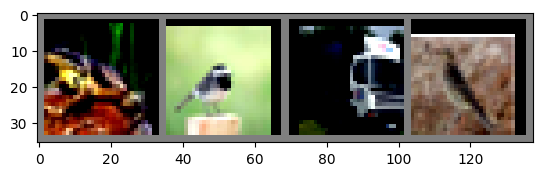

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# Función para desnormalizar y mostrar las imágenes
def imshow(img):
    # Desnormalizar las imágenes (volver a escala [0, 1])
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Obtener un batch de datos
dataiter = iter(trainloader)
images, labels = next(dataiter)  # Usar next() en lugar de next()

# Mostrar las primeras 4 imágenes del batch
imshow(torchvision.utils.make_grid(images[:4]))

Normalizamos las imágenes 

In [71]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1) #Aplicamos 32 filtro y cada uno de ellos detecta patrones como los bordes o texturas
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) #Detecta patrones más complejos
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) #Reduce el tamaño
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 10)
        

    def forward(self, x):
        x = torch.relu(self.conv1(x))   # [32, 32, 32]
        x = self.pool(x)                # [32, 16, 16]
        
        x = torch.relu(self.conv2(x))   # [64, 16, 16]
        x = self.pool(x)  

        x = torch.relu(self.conv3(x))
        x = self.pool(x)   # 8x8 -> 4x4             # [64, 8, 8]
        
        x = torch.flatten(x, 1) 
                # [128*4*4]
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x




Establecemos el modelo, función de pérdida y optimizador

In [72]:
model = SimpleCNN()

for name, param in model.named_parameters():
    print(name, param.shape) #Comprobamos que tenga información

#Función de pérdida
#Ya que se trata de un problema de multiclase utilizaremos crossEntropy
criterion = nn.CrossEntropyLoss()

#Ahora el optimizador
#Como es multiclase utilizamos Adam
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)


conv1.weight torch.Size([32, 3, 3, 3])
conv1.bias torch.Size([32])
conv2.weight torch.Size([64, 32, 3, 3])
conv2.bias torch.Size([64])
conv3.weight torch.Size([128, 64, 3, 3])
conv3.bias torch.Size([128])
fc1.weight torch.Size([128, 2048])
fc1.bias torch.Size([128])
fc2.weight torch.Size([10, 128])
fc2.bias torch.Size([10])


In [ ]:
train_loss = []
val_loss = []

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs,labels in trainloader:
        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(trainloader)
    train_loss.append(epoch_train_loss)

    #Validación

    model.eval()
    val_running_loss= 0.0
    with torch.no_grad():
        for inputs, labels in testloader:
            val_outputs = model(inputs)
            val_loss_val = criterion(val_outputs,labels)
            val_running_loss += val_loss_val.item()

    epoch_val_loss = val_running_loss / len(testloader)
    val_loss.append(epoch_val_loss)


    if (epoch + 1) % 1 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss Train: {epoch_train_loss:.4f}, Loss Val: {epoch_val_loss:.4f}')

plt.plot(range(1, num_epochs+1), train_loss, label="Pérdida entrenamiento")
plt.plot(range(1, num_epochs+1), val_loss, label="Pérdida validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Evolución de la Pérdida")
plt.legend()
plt.show()

Epoch [1/10], Loss Train: 1.7214, Loss Val: 1.3379
Epoch [2/10], Loss Train: 1.4037, Loss Val: 1.1023


In [ ]:
torch.save(model.state_dict(), 'thyroid_model.pth') #Guardamos el modelo entrenado